<a href="https://colab.research.google.com/github/m28851119-cmd/Deep-Clustering/blob/main/%E6%B7%B1%E5%BA%A6%E8%81%9A%E7%B1%BBMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 导包


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from tqdm import tqdm

#  1. 环境与数据准备

In [17]:
# ==========================================
# 1. 环境与全量数据准备 (MNIST 60,000张)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前运行设备: {device}")

# MNIST 只需要简单的标准化
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 加载全量训练集 (MNIST 默认 6万张)
full_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(full_dataset, batch_size=256, shuffle=True, num_workers=2)
# 用于评估的顺序 Loader
dataloader_plain = DataLoader(full_dataset, batch_size=256, shuffle=False, num_workers=2)

def cluster_eval(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    D = max(y_pred.max(), y_true.max()) + 1
    w = np.zeros((D, D), dtype=np.int64)
    for i in range(y_pred.size): w[y_pred[i], y_true[i]] += 1
    row_ind, col_ind = linear_sum_assignment(w.max() - w)
    return sum([w[i, j] for i, j in zip(row_ind, col_ind)]) / y_pred.size

# 提取全量原始数据
print("提取 MNIST 原始像素数据...")
X_raw_list, Y_true_list = [], []
for imgs, labels in dataloader_plain:
    X_raw_list.append(imgs.view(imgs.size(0), -1).numpy())
    Y_true_list.append(labels.numpy())
X_raw = np.concatenate(X_raw_list)
Y_true = np.concatenate(Y_true_list)

当前运行设备: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.42MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.07MB/s]

提取 MNIST 原始像素数据...


# 2. 方案一 & 方案二（传统方法）

In [18]:
# ==========================================
# 2. 方案一 & 方案二 (MNIST 版)
# ==========================================
print("\n[方案一] 运行 K-means (原始像素)...")
km = KMeans(n_clusters=10, n_init=10, random_state=42)
y_pred1 = km.fit_predict(X_raw)
acc1 = cluster_eval(Y_true, y_pred1)
print(f"方案一结果: ACC={acc1:.4f}")

print("[方案二] 运行 PCA + K-means (50维)...")
X_pca = PCA(n_components=50).fit_transform(X_raw)
y_pred2 = km.fit_predict(X_pca)
acc2 = cluster_eval(Y_true, y_pred2)
print(f"方案二结果: ACC={acc2:.4f}")


[方案一] 运行 K-means (原始像素)...
方案一结果: ACC=0.5135
[方案二] 运行 PCA + K-means (50维)...
方案二结果: ACC=0.5129


# 3. 方案三：完整卷积 DEC

In [19]:
# ==========================================
# 3. 方案三：卷积 DEC (针对 28x28 优化)
# ==========================================

class ConvAE(nn.Module):
    def __init__(self):
        super(ConvAE, self).__init__()
        # 编码器：28x28 -> 14x14 -> 7x7 -> 512
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(), # 14x14
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(), # 7x7
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 512)
        )
        # 解码器
        self.decoder = nn.Sequential(
            nn.Linear(512, 64 * 7 * 7),
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1), nn.Tanh()
        )
    def forward(self, x):
        z = self.encoder(x)
        return z, self.decoder(z)

class ClusteringLayer(nn.Module):
    def __init__(self, n_clusters=10, latent_dim=512):
        super(ClusteringLayer, self).__init__()
        self.centers = nn.Parameter(torch.zeros(n_clusters, latent_dim))
        nn.init.xavier_uniform_(self.centers)
    def forward(self, z):
        q = 1.0 / (1.0 + torch.sum((z.unsqueeze(1) - self.centers)**2, dim=2))
        return q / q.sum(dim=1, keepdim=True)

def get_target_p(q):
    p = q**2 / q.sum(dim=0)
    return p / p.sum(dim=1, keepdim=True)

# A. 预训练 (MNIST 很快，50轮足矣)
print("\n[方案三] 步骤 A: 预训练 (50 Epochs)...")
model = ConvAE().to(device)
opt_ae = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(50):
    model.train()
    pbar = tqdm(dataloader, desc=f"AE Epoch {epoch+1}/50", leave=False)
    for imgs, _ in pbar:
        imgs = imgs.to(device)
        _, recon = model(imgs)
        loss = F.mse_loss(recon, imgs)
        opt_ae.zero_grad(); loss.backward(); opt_ae.step()

# B. 初始化中心
print("步骤 B: K-means 初始化...")
model.eval()
all_z = []
with torch.no_grad():
    for imgs, _ in dataloader_plain:
        all_z.append(model.encoder(imgs.to(device)).cpu().numpy())
all_z = np.concatenate(all_z)
km_init = KMeans(n_clusters=10, n_init=20).fit(all_z)

# C. 深度联合优化 (50轮)
print("\n步骤 C: 深度联合优化 (50 Epochs)...")
cl_layer = ClusteringLayer().to(device)
cl_layer.centers.data.copy_(torch.tensor(km_init.cluster_centers_))
opt_dec = optim.SGD(list(model.encoder.parameters()) + list(cl_layer.parameters()), lr=0.01, momentum=0.9)

for epoch in range(50):
    model.encoder.train()
    pbar = tqdm(dataloader, desc=f"DEC Epoch {epoch+1}/50", leave=False)
    for imgs, _ in pbar:
        imgs = imgs.to(device)
        z = model.encoder(imgs)
        q = cl_layer(z); p = get_target_p(q).detach()
        loss = F.kl_div(q.log(), p, reduction='batchmean')
        opt_dec.zero_grad(); loss.backward(); opt_dec.step()

# D. 最终评估与可视化
model.eval()
final_z = []
with torch.no_grad():
    for imgs, _ in dataloader_plain:
        final_z.append(model.encoder(imgs.to(device)).cpu().numpy())
final_z = np.concatenate(final_z)
y_pred3 = cl_layer(torch.tensor(final_z).to(device)).argmax(dim=1).cpu().numpy()
acc3 = cluster_eval(Y_true, y_pred3)


[方案三] 步骤 A: 预训练 (50 Epochs)...


步骤 B: K-means 初始化...



步骤 C: 深度联合优化 (50 Epochs)...


# 可视化对比


生成 t-SNE 可视化图表...


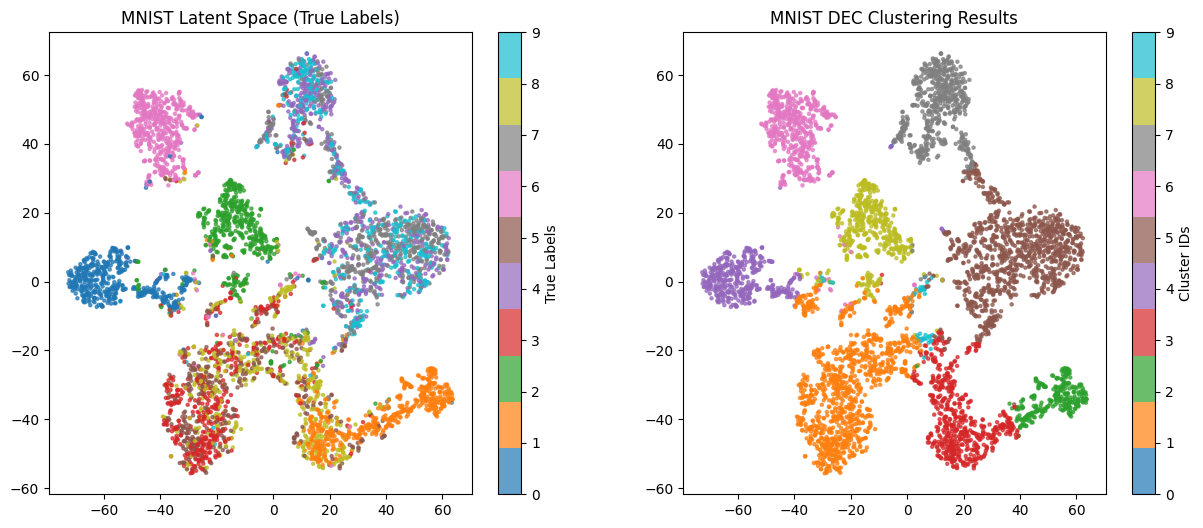

In [20]:
# 可视化对比 (取前5000张)
print("\n生成 t-SNE 可视化图表...")
tsne = TSNE(n_components=2, random_state=42)
z_vis = tsne.fit_transform(final_z[:5000])

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.scatter(z_vis[:, 0], z_vis[:, 1], c=Y_true[:5000], cmap='tab10', s=5, alpha=0.7)
plt.colorbar(label='True Labels')
plt.title("MNIST Latent Space (True Labels)")

plt.subplot(1, 2, 2)
plt.scatter(z_vis[:, 0], z_vis[:, 1], c=y_pred3[:5000], cmap='tab10', s=5, alpha=0.7)
plt.colorbar(label='Cluster IDs')
plt.title("MNIST DEC Clustering Results")
plt.show()



# 对比

In [21]:
print("\n" + "="*40)
print(f"方案一 K-means (像素):     ACC={acc1:.4f}")
print(f"方案二 PCA+K-means:       ACC={acc2:.4f}")
print(f"方案三 卷积 DEC:          ACC={acc3:.4f}")
print("="*40)



方案一 K-means (像素):     ACC=0.5135
方案二 PCA+K-means:       ACC=0.5129
方案三 卷积 DEC:          ACC=0.5742
